# Extended Data Fig. 8 | Local examples of mangrove deforestation events after 2020.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from shapely.geometry import box
import matplotlib as mpl
import geopandas as gpd
import cartopy.crs as ccrs
import ZhenPlot
import os
import ee
ee.Authenticate()
ee.Initialize()

import tropycal.tracks as tracks
import tropycal.utils as utils

plt.rcParams['font.sans-serif'] = ['Arial']
%config InlineBackend.figure_format = 'retina'

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [ ]:
os.chdir(r'D:\OneDriveFolder\OneDrive\Manuscript\GlobalMangroveDynamics\code')
ibtracs = tracks.TrackDataset(basin='all', source='ibtracs', include_btk=False)

loss_2223 = gpd.read_file('Code_Data/Loss_2022-2023.shp').to_crs(epsg=4326)
loss_2021 = gpd.read_file('Code_Data/Loss_2020-2021.shp').to_crs(epsg=4326)
loss_1823 = gpd.read_file('Code_Data/Loss_2018-2023.shp').to_crs(epsg=4326)

--> Starting to read in ibtracs data
--> Completed reading in ibtracs data (103.81 seconds)


In [56]:
def plot_cyclone(ax,storm,bounding):
    """This function plots a tropical cyclone track on the provided axes."""
    import cartopy.feature as cfeature
    lons,lats = np.array(storm.lon), np.array(storm.lat)
    u,v = np.diff(lons), np.diff(lats)
    mid_lons,mid_lats = (lons[:-1] + lons[1:]) / 2,(lats[:-1] + lats[1:]) / 2
    ZhenPlot.add_basemap(ax,xticks=True,yticks=True,
                         xrange=np.arange(bounding[0],bounding[1],5),
                         yrange=np.arange(bounding[2],bounding[3],5),fontsize=10,ocean_color='white')
    ax.add_feature(cfeature.LAND,color='#bfbebe')
    ax = utils.add_tropycal(ax)
    ax.quiver(mid_lons, mid_lats, u, v, transform=ccrs.PlateCarree(),
          angles='xy', scale_units='xy', scale=1, color='k', width=0.006,zorder=2)
    ax.set_extent(bounding)
    return ax

loss_layers = [loss_2223,loss_2223,loss_2223,loss_2021,loss_1823,loss_2223]
cyclone_info = {'ian':2022, 
                 'roslyn':2022} 
bigregions = [[-82,24],[-105.5,22],[-53.8,5.7],[-97.1,27.87],[39.36, -7.98],[122.25,-3.61]] 
bigsteps = [10,10,0.2,0.2,0.5,0.3]
landsat_regions = [[-82.15,26.55],[-105.5,22],[-53.73,5.675],[-97.075,27.88],[39.265, -7.84],[122.245,-3.49]]
smallsteps = [0.3,0.6,0.05,0.05,0.09,0.06]
titles = ['Hurricane Ian (2022)','Hurricane Roslyn (2022)','French Guiana','Texas','Rufiji Delta','Sulawesi']

landsat_years = [[2022,2023],[2022,2023],[2022,2023],[2020,2021],[2018,2023],[2022,2023]]

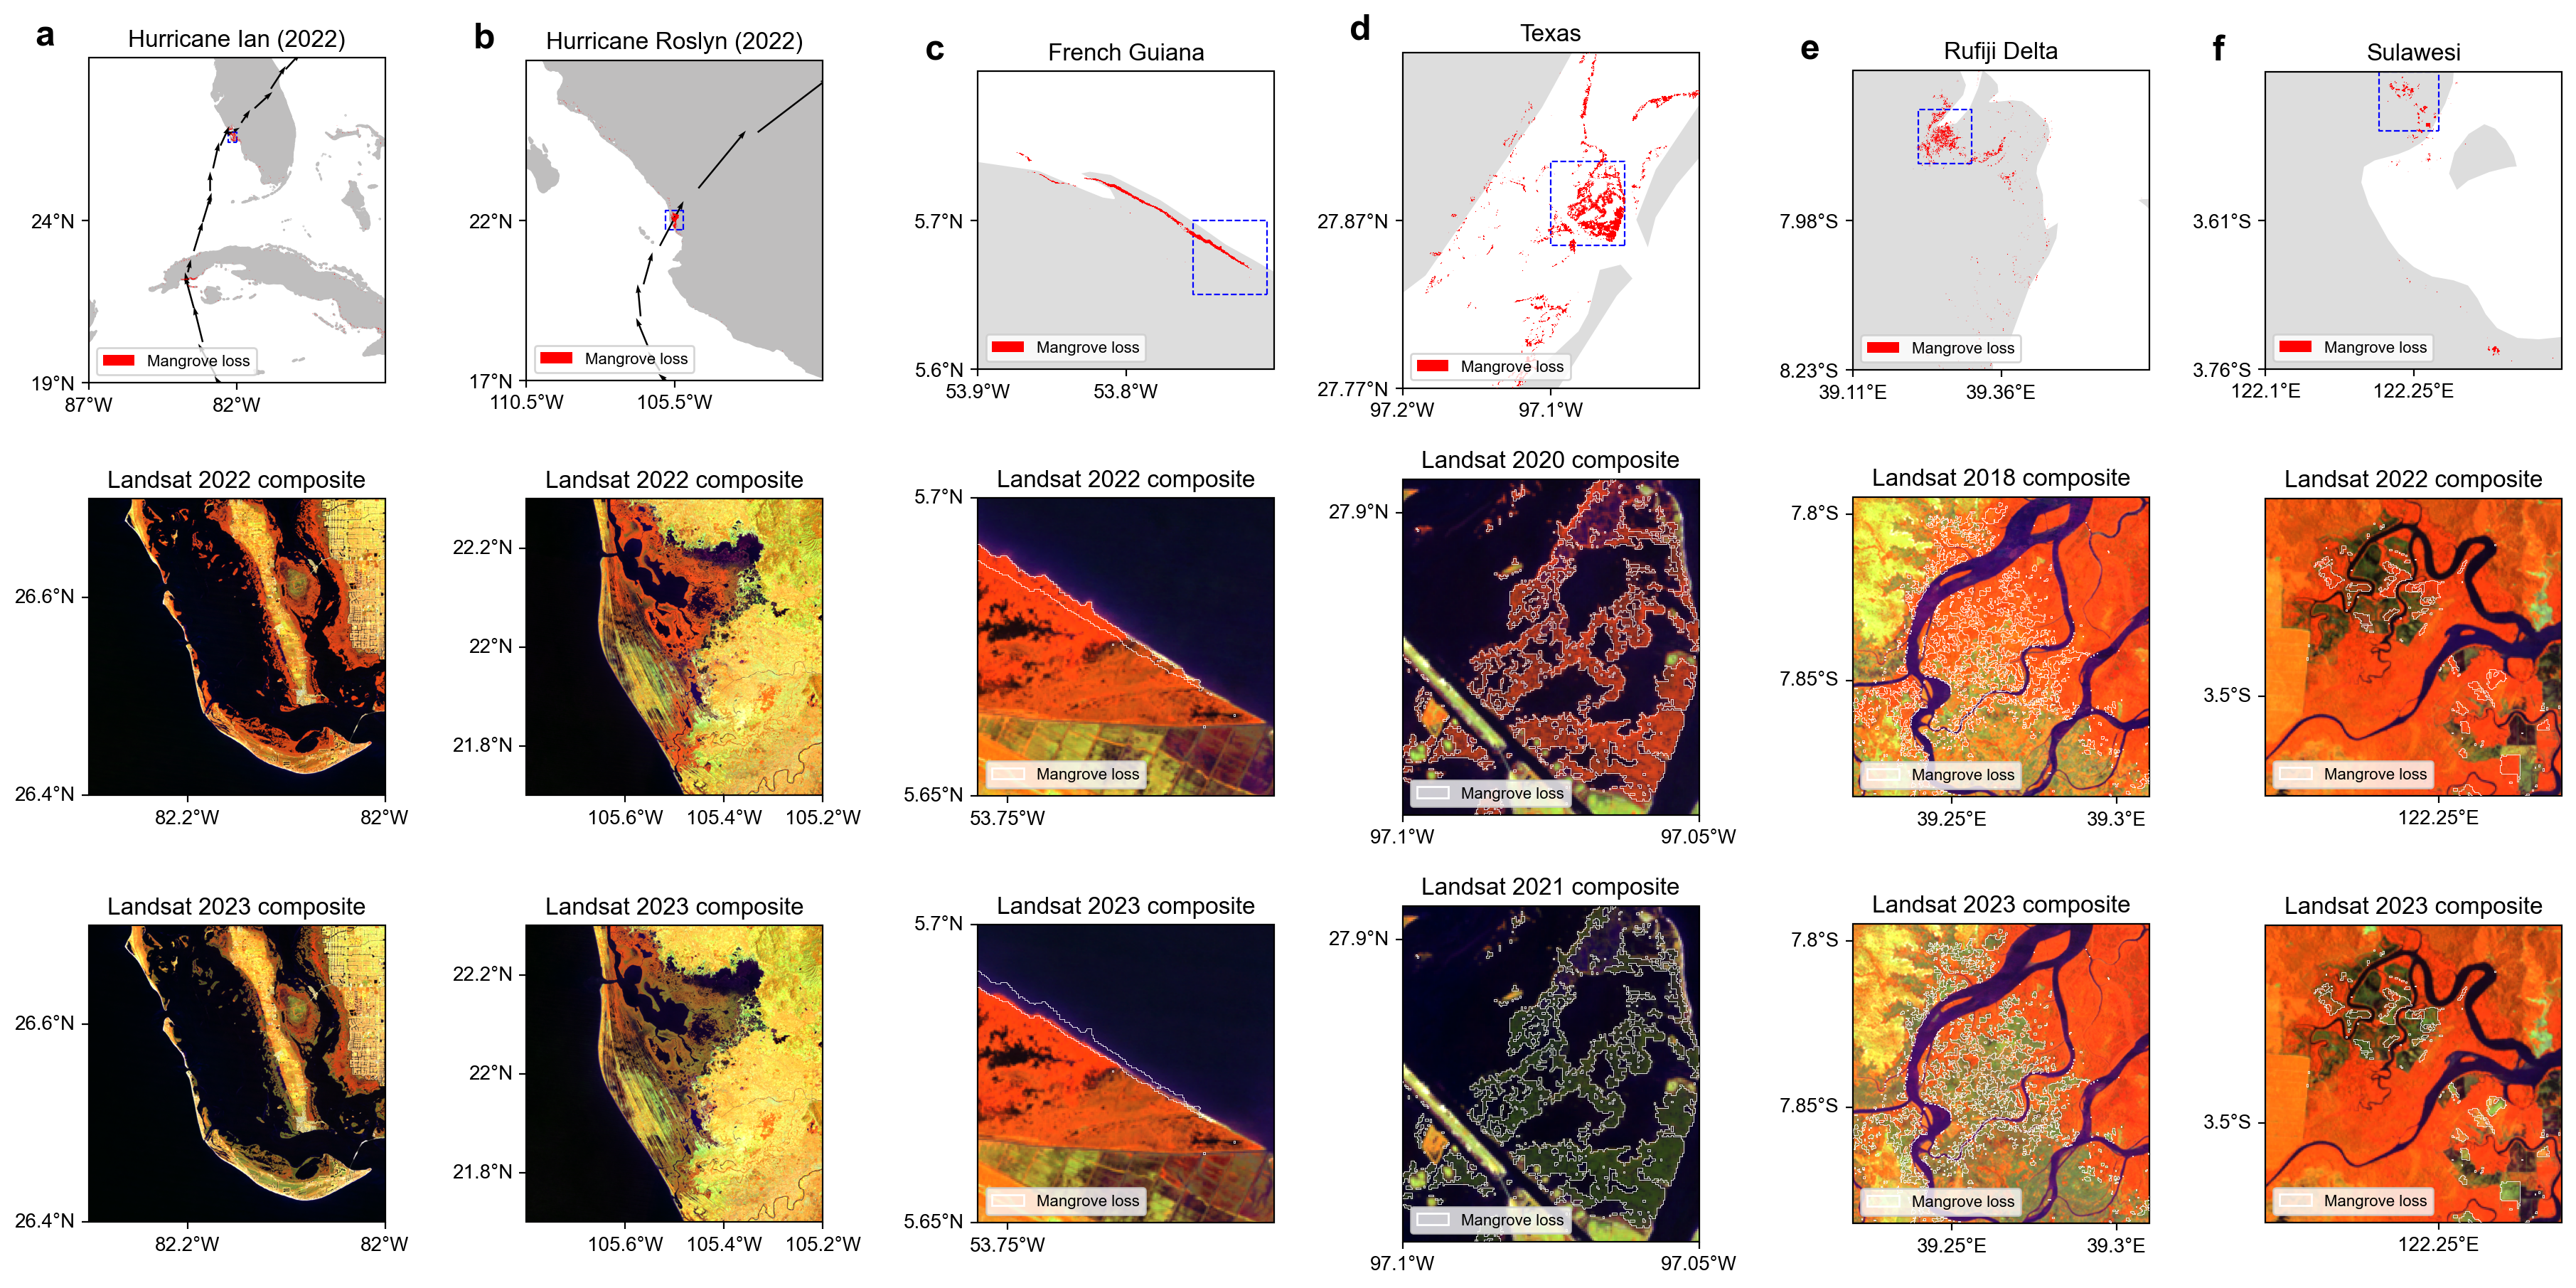

In [ ]:
fig = plt.figure(figsize=(18, 9),constrained_layout=True)
gs = GridSpec(nrows=3, ncols=6,figure=fig,wspace=0.1)

for col in range(6):
    ax_row0 = fig.add_subplot(gs[0,col],projection=ccrs.PlateCarree())
    ax_row1 = fig.add_subplot(gs[1,col],projection=ccrs.PlateCarree())
    ax_row2 = fig.add_subplot(gs[2,col],projection=ccrs.PlateCarree())
    bigregion = ZhenPlot.generating_extent(bigregions[col],xresolution=bigsteps[col],yresolution=bigsteps[col])
    smallregion = ZhenPlot.generating_extent(landsat_regions[col],xresolution=smallsteps[col],yresolution=smallsteps[col])
    ax_row0.text(-0.18, 1.04, 'abcdef'[col], transform=ax_row0.transAxes, fontsize=18, fontweight='bold')
    ax_row0.add_geometries([box(smallregion[0], smallregion[2], smallregion[1], smallregion[3])], 
                        ccrs.PlateCarree(),facecolor='none',edgecolor="blue",linewidth=0.8,linestyle='--', zorder=2)
    ax_row0.set_title(titles[col],fontsize=12)
    if col < 2:
        cyclonename = list(cyclone_info.keys())[col]
        storm = ibtracs.get_storm((cyclonename, cyclone_info[cyclonename]))
        plot_cyclone(ax_row0,storm,bigregion)
       
    else:
        ZhenPlot.add_basemap(ax_row0,xticks=True,yticks=True,
                         xrange=np.arange(bigregion[0],bigregion[1],abs(bigregion[1]-bigregion[0])/2),
                         yrange=np.arange(bigregion[2],bigregion[3],abs(bigregion[3]-bigregion[2])/2),fontsize=10,ocean_color='white')
    loss_layer = loss_layers[col].cx[bigregion[0]:bigregion[1], bigregion[2]:bigregion[3]]
    loss_layer.plot(ax=ax_row0, facecolor='red', edgecolor='red',linewidth=0.05, alpha=1, zorder=3)
    legend_elements = [Patch(facecolor='red', label='Mangrove loss')]
    ax_row0.legend(handles=legend_elements,ncol=1, loc='lower left', frameon=True, fontsize=8)
    ax_row0.set_extent(bigregion)
    
    for row,ax in enumerate([ax_row1,ax_row2]):
        if col < 2:
            interval = 0.2
        else:
            interval = 0.05
        ZhenPlot.plot_landsat(ax,str(landsat_years[col][row])+'-01-01',str(landsat_years[col][row])+'-12-31',smallregion,interval=interval,zorder=2)
        ax.set_title(f'Landsat {landsat_years[col][row]} composite',fontsize=12)
        if col >= 2:
            loss_layer.plot(ax=ax, facecolor='none', edgecolor='white',linewidth=0.3, alpha=1, zorder=3)
            legend_elements = [Patch(facecolor='none', edgecolor='white', label='Mangrove loss')]
            ax.legend(handles=legend_elements,ncol=1, loc='lower left', frameon=True, fontsize=8)
        ax.set_extent(smallregion)
    # break
plt.savefig("Figures/RecentLosses.svg", dpi=500, format='svg', bbox_inches='tight')
plt.savefig("Figures/RecentLosses.png", dpi=500, format='png', bbox_inches='tight')